# Summary of EDA

**Dataset Description** [Source](https://dl.acm.org/doi/pdf/10.1145/3308558.3313643)

**Main dataset**
1. **Altitude**: Array[500], unit=Degree
2. **Longitude**: Array[500], unit=Degree
3. **Heart Rate**: Array[500], unit=Beat per Minute
4. **Timestamp**: Array[500], unit=UNIX Timestamp
5. **Speed**: Array[500] or NULL, unit=Miles per Hour


**Metadata**

1. It has a lot of missing values on many columns.
2. For columns where there aren't many missing values, the range don't make sense. Need to remove outliers.
3. Weather can't be used because we don't have a mapping of integer type to the actual weather.
4. Imputing ascent and descent seems illogical. What if the activity is something that doesn't require ascent/descent? Need more explore to determine if this metadata can be used.
   

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
import datetime

import numpy as np

from pyspark.sql import SparkSession
from pyspark.sql.functions import size, mean, explode, udf, count_distinct, abs, median
from pyspark.sql.types import IntegerType, ArrayType, FloatType

In [2]:
# Initiate spark session
spark = SparkSession.builder.config("spark.driver.port", "1234").appName('fitrec').getOrCreate()

# Load data
path = '../data/endomondoHR_proper.json'
df = spark.read.json(path)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/20 13:17:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

In [3]:
df.printSchema()

root
 |-- altitude: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- gender: string (nullable = true)
 |-- heart_rate: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- id: long (nullable = true)
 |-- latitude: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- longitude: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- speed: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- sport: string (nullable = true)
 |-- timestamp: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- url: string (nullable = true)
 |-- userId: long (nullable = true)



In [4]:
# We probably don't need this column
df = df.drop('url')

In [5]:
df.show(1, vertical=True)

-RECORD 0--------------------------
 altitude   | [41.6, 40.6, 40.6... 
 gender     | male                 
 heart_rate | [100, 111, 120, 1... 
 id         | 396826535            
 latitude   | [60.1733487658202... 
 longitude  | [24.6497704088687... 
 speed      | [6.8652, 16.4736,... 
 sport      | bike                 
 timestamp  | [1408898746, 1408... 
 userId     | 10921915             
only showing top 1 row



In [6]:
unique_users = df.select('userId').distinct().count()

print(f'There are {unique_users} users in the dataset')

[Stage 2:=======================================================> (36 + 1) / 37]

There are 1059 users in the dataset


### How many workouts per user?

Text(0.5, 1.0, 'Frequency of workout per user')

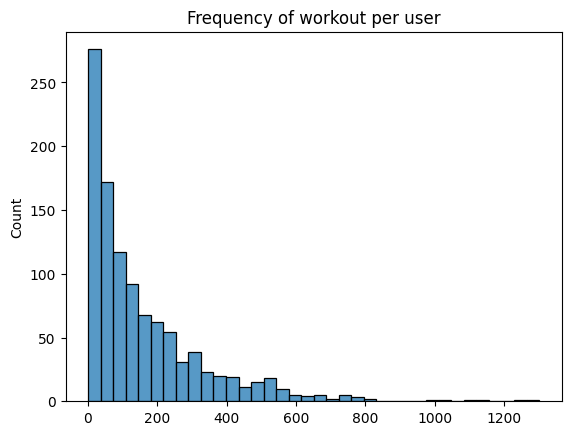

In [7]:
# Graph how many rows a user typically has
result = df.groupby('userId').count().collect()
user_ids = [row['userId'] for row in result]
workout_count = [row['count'] for row in result]

sns.histplot(x=workout_count)
plt.title('Frequency of workout per user')

# Workout Habit

In [8]:
user_id = df.select('userId').take(1)[0]
user_id.userId

10921915

In [9]:
df.filter(df.userId == user_id.userId).select('sport', 'heart_rate', 'timestamp').show()

+----------------+--------------------+--------------------+
|           sport|          heart_rate|           timestamp|
+----------------+--------------------+--------------------+
|            bike|[100, 111, 120, 1...|[1408898746, 1408...|
|            bike|[100, 105, 111, 1...|[1408221682, 1408...|
|            bike|[99, 105, 113, 11...|[1407858459, 1407...|
|            bike|[99, 105, 113, 10...|[1407432042, 1407...|
|bike (transport)|[110, 113, 114, 1...|[1406909434, 1406...|
|bike (transport)|[106, 110, 113, 1...|[1406665232, 1406...|
|bike (transport)|[118, 118, 119, 1...|[1406647079, 1406...|
|bike (transport)|[112, 115, 118, 1...|[1406580617, 1406...|
|            bike|[100, 108, 101, 9...|[1405281638, 1405...|
|            bike|[100, 98, 104, 10...|[1405100572, 1405...|
|            bike|[107, 112, 115, 1...|[1404774259, 1404...|
|bike (transport)|[99, 107, 117, 12...|[1404492369, 1404...|
|            bike|[91, 100, 107, 10...|[1404415397, 1404...|
|            bike|[98, 9

In [10]:
# Distinct workouts this user has done
df.filter(df.userId == user_id.userId).select('sport').distinct().show()

[Stage 13:===================================>                   (24 + 12) / 37]

+----------------+
|           sport|
+----------------+
|bike (transport)|
|            bike|
+----------------+



In [11]:
# Q: How many unique workout each user has done?

result = df.groupby('userId').agg(count_distinct('sport')).sort('userId').collect()

Text(0.5, 1.0, 'Unique workout per user')

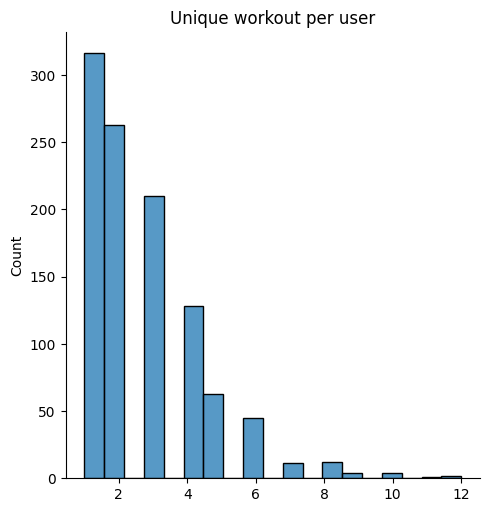

In [12]:
user_ids = [row[0] for row in result]
sport_per_user = [row[1] for row in result]

sns.displot(x=sport_per_user)
plt.title('Unique workout per user')

### How many unique categorical variables?

In [13]:
df.drop_duplicates(['sport']).select('sport').show()

[Stage 29:=================================================>      (33 + 4) / 37]

+--------------------+
|               sport|
+--------------------+
|       mountain bike|
|cross-country skiing|
|              hiking|
|            kayaking|
|        orienteering|
|              rowing|
|    bike (transport)|
|      indoor cycling|
|                walk|
|               skate|
|                 run|
|core stability tr...|
|              tennis|
|                bike|
|     weight training|
|          elliptical|
|              soccer|
|   treadmill running|
|    circuit training|
|          basketball|
+--------------------+
only showing top 20 rows



In [14]:
df.groupby('sport').agg(count_distinct('userId')).sort('count(DISTINCT userId)').show(df.count(), truncate=False)

[Stage 35:========================================>              (27 + 10) / 37]

+-----------------------+----------------------+
|sport                  |count(DISTINCT userId)|
+-----------------------+----------------------+
|windsurfing            |1                     |
|kite surfing           |1                     |
|sailing                |1                     |
|yoga                   |1                     |
|table tennis           |1                     |
|squash                 |1                     |
|rugby                  |1                     |
|badminton              |1                     |
|treadmill walking      |1                     |
|martial arts           |1                     |
|pilates                |2                     |
|basketball             |2                     |
|stair climing          |2                     |
|climbing               |2                     |
|snowboarding           |3                     |
|horseback riding       |4                     |
|tennis                 |4                     |
|golf               

# Q: How many male vs female users?

In [15]:
df.groupby('gender').agg(count_distinct('userId')).show()

[Stage 41:======================================================> (36 + 1) / 37]

+-------+----------------------+
| gender|count(DISTINCT userId)|
+-------+----------------------+
|unknown|                    15|
| female|                   101|
|   male|                   943|
+-------+----------------------+



# Q: What's the avg heart rate per workout?

In [20]:
# Function to calculate mean per column
array_mean = udf(lambda x: float(np.mean(x)), FloatType())

df.filter(df.userId==430859).select('userId', 'sport', array_mean('heart_rate').alias('avg heart rate')).show()

+------+----------------+--------------+
|userId|           sport|avg heart rate|
+------+----------------+--------------+
|430859|            bike|       130.396|
|430859|            bike|       135.242|
|430859|            bike|       129.192|
|430859|            bike|        121.28|
|430859|            bike|       116.436|
|430859|            bike|       130.772|
|430859|            bike|         131.9|
|430859|            bike|        135.26|
|430859|            bike|       140.356|
|430859|            bike|       131.748|
|430859|            bike|       126.774|
|430859|            bike|         119.6|
|430859|            bike|       126.238|
|430859|bike (transport)|       116.194|
|430859|            bike|       133.414|
|430859|            bike|       141.222|
|430859|            bike|       130.934|
|430859|            bike|       129.312|
|430859|bike (transport)|       111.406|
|430859|bike (transport)|       111.044|
+------+----------------+--------------+
only showing top

# Main Data Check

In [21]:
# Check the number of nulls in each column
null_dict = {col: 0 for col in df.columns}

for col in df.columns:
    null_count = df.filter(df[col].isNull()).count()
    null_dict[col] = null_count

In [22]:
null_dict

{'altitude': 0,
 'gender': 0,
 'heart_rate': 0,
 'id': 0,
 'latitude': 0,
 'longitude': 0,
 'speed': 136110,
 'sport': 0,
 'timestamp': 0,
 'userId': 0}

In [23]:
# For which sport does speed is null?
df.filter(df.speed.isNull()).groupby('sport').count().sort('count').show(df.count())

[Stage 81:====================================================>   (35 + 2) / 37]

+--------------------+-----+
|               sport|count|
+--------------------+-----+
|                yoga|    1|
|   treadmill walking|    1|
|             sailing|    1|
|        kite surfing|    1|
|              squash|    1|
|        martial arts|    1|
|         windsurfing|    1|
|        snowboarding|    3|
|       stair climing|    3|
|             pilates|    3|
|               rugby|    3|
|        table tennis|    4|
|            climbing|    5|
|            aerobics|    7|
|              tennis|    8|
|          basketball|    8|
|    horseback riding|    9|
|          elliptical|   10|
|           badminton|   10|
|                golf|   12|
|            swimming|   14|
|         snowshoeing|   16|
|   treadmill running|   28|
|     downhill skiing|   48|
|              soccer|   51|
|          gymnastics|   66|
|              rowing|   71|
|     weight training|   74|
|            kayaking|   82|
|    circuit training|   89|
|       roller skiing|  219|
|             

In [24]:
# Get the dimension of each of the column
col_names = ['altitude', 'longitude', 'timestamp', 'heart_rate', 'speed']

for col in col_names:
    col_size = df.select(size(df[col])).distinct().collect()
    col_size = [sz[0] for sz in col_size]
    
    print(f'The column {col} is an array of size [{col_size}].')


The column altitude is an array of size [[500]].


The column longitude is an array of size [[500]].


The column timestamp is an array of size [[500]].


The column heart_rate is an array of size [[500]].


[Stage 96:===================================>                   (24 + 12) / 37]

The column speed is an array of size [[-1, 500]].


Speed is generally missing for a lot of workout type. Is there any way we can impute the missing values?

Maybe for same activity with average speed --> we can impute the speed?

# Metadata Check

In [25]:
metadata_path = '../data/endomondoMeta.json'
metadata = spark.read.json(metadata_path)

In [26]:
metadata = metadata.drop('url')

In [27]:
metadata.printSchema()

root
 |-- ascent: string (nullable = true)
 |-- calories: string (nullable = true)
 |-- descent: string (nullable = true)
 |-- distance: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- hydration: string (nullable = true)
 |-- id: long (nullable = true)
 |-- sport: string (nullable = true)
 |-- timestamp: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- userId: long (nullable = true)
 |-- weather: string (nullable = true)



In [28]:
metadata.show(1, vertical=True)

-RECORD 0-------------------------
 ascent    | 147.0                
 calories  | 1313.0               
 descent   | 137.0                
 distance  | 18.85551             
 duration  | 3218.35              
 gender    | male                 
 hydration | None                 
 id        | 322483826            
 sport     | mountain bike        
 timestamp | [2014-04-11T14:32... 
 userId    | 10014612             
 weather   | {"type":7}           
only showing top 1 row



In [29]:
# Numbe of rows
metadata_rows = metadata.count()

In [30]:
# Check the number of nulls in each column
meta_nulls = {col: 0 for col in metadata.columns if col != 'timestamp'}

for col in [col for col in metadata.columns if col != 'timestamp']:
    null_count = metadata.filter(metadata[col] == 'None').count()
    meta_nulls[col] = null_count

meta_nulls

{'ascent': 66352,
 'calories': 5041,
 'descent': 66398,
 'distance': 7406,
 'duration': 8,
 'gender': 0,
 'hydration': 680448,
 'id': 0,
 'sport': 0,
 'userId': 0,
 'weather': 291924}

In [31]:
for k, v in meta_nulls.items():
    print(f'{k:12} missing \t {round((v / metadata_rows) * 100, 6)}%')

ascent       missing 	 6.895935%
calories     missing 	 0.523909%
descent      missing 	 6.900716%
distance     missing 	 0.769702%
duration     missing 	 0.000831%
gender       missing 	 0.0%
hydration    missing 	 70.718673%
id           missing 	 0.0%
sport        missing 	 0.0%
userId       missing 	 0.0%
weather      missing 	 30.339538%


Metadata we can use readily (by just dropping the rows where there are nulls):
- calories
- distance
- duration


In [32]:
# Cast to double type for descriptive statistics
usable_metadata = metadata.select(metadata.calories.cast('double'),
                                  metadata.distance.cast('double'),
                                  metadata.duration.cast('double'),
                                  'id')
usable_metadata.printSchema()

root
 |-- calories: double (nullable = true)
 |-- distance: double (nullable = true)
 |-- duration: double (nullable = true)
 |-- id: long (nullable = true)



In [33]:
# Descriptive statistics
usable_metadata.select('calories', 'distance', 'duration').describe().show()

[Stage 135:=========================================>            (61 + 12) / 80]

+-------+------------------+------------------+-----------------+
|summary|          calories|          distance|         duration|
+-------+------------------+------------------+-----------------+
|  count|            957149|            954784|           962182|
|   mean|3138.4148639163177|20.432923638320784|8114.384976659189|
| stddev|2196162.1395672383| 4395.646176665107|615281.5000284669|
|    min|          -1542.89|         -10.06844|         -13749.0|
|    max|      2.14748006E9|       4294967.295|        2.60388E8|
+-------+------------------+------------------+-----------------+



# Merge main DF and metadata

In [34]:
# Join main frame and metadata by the id of the rows
joined_df = df.join(usable_metadata, 'id')

In [35]:
# Count number of users
joined_df.groupby('userId').count().count()

1059

In [37]:
# Show example of row
joined_df.show(1, vertical=True)


[Stage 157:================================================>      (71 + 9) / 80]

-RECORD 0--------------------------
 id         | 1600353              
 altitude   | [24.523, 26.842, ... 
 gender     | male                 
 heart_rate | [98, 100, 112, 11... 
 latitude   | [55.45047, 55.450... 
 longitude  | [11.542013, 11.54... 
 speed      | NULL                 
 sport      | bike                 
 timestamp  | [1279234743, 1279... 
 userId     | 139383               
 calories   | 3472.0               
 distance   | 86.09915625          
 duration   | 9526.23              
only showing top 1 row



<Axes: >

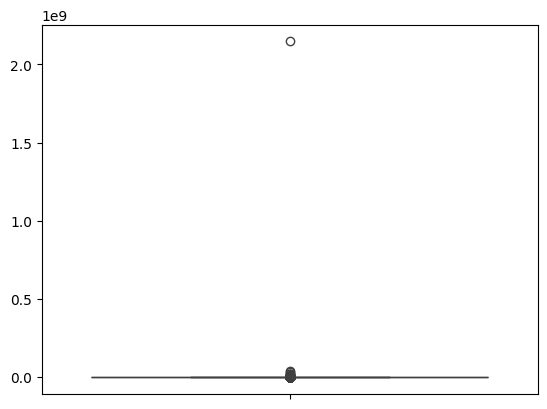

In [44]:
# Get the calories column and draw a boxplot
calories = usable_metadata.select('calories').collect()
sns.boxplot([row.calories for row in calories])

In [56]:
# Q: Is 0 calories workout a mistake?
joined_df.filter(joined_df.calories == 0).select('userId','distance', 'calories').show(10, vertical=True)

-RECORD 0----------------------
 userId   | 10057948           
 distance | 50.185379999999995 
 calories | 0.0                
-RECORD 1----------------------
 userId   | 10057948           
 distance | 43.68074           
 calories | 0.0                
-RECORD 2----------------------
 userId   | 10057948           
 distance | 39.7753            
 calories | 0.0                
-RECORD 3----------------------
 userId   | 10057948           
 distance | 40.78465           
 calories | 0.0                
-RECORD 4----------------------
 userId   | 10057948           
 distance | 24.68351           
 calories | 0.0                
-RECORD 5----------------------
 userId   | 10057948           
 distance | 22.39755           
 calories | 0.0                
-RECORD 6----------------------
 userId   | 10057948           
 distance | 21.28661           
 calories | 0.0                
-RECORD 7----------------------
 userId   | 10057948           
 distance | 21.159             
 calorie

Maybe the smart watch of the user doesn't have the calories counting capability on.

In [55]:
# Number of workout that doesn't use any calories :)
joined_df.filter(joined_df.calories <= 0).count()

778

In [57]:
# Number of stationary (or negative distance) workout
joined_df.filter(joined_df.distance <= 0).count()

11

In [58]:
# Number of workout out that doesn't happen :)
joined_df.filter(joined_df.duration <= 0).count()

0

In [61]:
# Check the range of duration
joined_df.select('duration').describe().show()

+-------+------------------+
|summary|          duration|
+-------+------------------+
|  count|            167779|
|   mean|11199.281718891116|
| stddev| 644546.2078389461|
|    min|               1.0|
|    max|         1.81416E8|
+-------+------------------+



In [66]:
# See the median value of workout duration per user
joined_df.groupby('userId').agg(median('duration')).describe()

+------+------------------+
|userId|  median(duration)|
+------+------------------+
|    69|         3224.2705|
|  2358|         2907.2835|
|  3808|3518.0869989000003|
|  4101|          3397.009|
|  4434|            3887.5|
|  5197|           3325.49|
|  5703|          3616.225|
|  5844|          4117.925|
| 13653|            3500.0|
| 16786|3104.0270642999994|
| 22260|           7009.49|
| 28064|           6170.02|
| 34269|          2853.353|
| 43169|            4780.0|
| 43462|           4815.32|
| 50404|          1285.766|
| 56291|3209.2009999999996|
| 56331|         4790.4035|
| 58536|            4756.9|
| 65350|          6954.748|
+------+------------------+
only showing top 20 rows



In [68]:
# See the median of the above table (workout statistics regardless of users)
joined_df.groupby('userId').agg(median('duration')).describe().show()

+-------+------------------+------------------+
|summary|            userId|  median(duration)|
+-------+------------------+------------------+
|  count|              1059|              1059|
|   mean| 5272293.757318225| 4419.890886039592|
| stddev|4101135.3149556345|1701.1554231330608|
|    min|                69|             654.0|
|    max|          15481421|12876.138500000001|
+-------+------------------+------------------+



In [78]:
# number of users who had workout lasting longer than 5 hours
joined_df.filter(joined_df.duration > 18000).groupby('userId').count().count()

14

## Fixing distance

In [86]:
# Descriptive statistics of distance column
joined_df.select('distance').describe().show()

+-------+------------------+
|summary|          distance|
+-------+------------------+
|  count|            167681|
|   mean|27.284765126575344|
| stddev| 69.28655034930696|
|    min|         -10.06844|
|    max|       26684.77344|
+-------+------------------+



In [91]:
# Filter out rows with less than 27 miles distance
joined_df.filter(joined_df.distance > 27).select('calories', 'distance').sort('distance').show(n=10, vertical=True)

-RECORD 0-----------------
 calories | 1042.0        
 distance | 27.00055      
-RECORD 1-----------------
 calories | 1592.0        
 distance | 27.0015300293 
-RECORD 2-----------------
 calories | 476.0         
 distance | 27.00204      
-RECORD 3-----------------
 calories | 598.0         
 distance | 27.0021999512 
-RECORD 4-----------------
 calories | 1647.0        
 distance | 27.00243      
-RECORD 5-----------------
 calories | 1911.0        
 distance | 27.0029       
-RECORD 6-----------------
 calories | 550.0         
 distance | 27.00311      
-RECORD 7-----------------
 calories | 646.0         
 distance | 27.0045900002 
-RECORD 8-----------------
 calories | 1427.0        
 distance | 27.00531      
-RECORD 9-----------------
 calories | 1724.0        
 distance | 27.0055799999 
only showing top 10 rows



In [92]:
# Filter out rows with less than or equal to 100 miles distance
joined_df.filter(joined_df.distance > 100).select('calories', 'distance').sort('distance').show(n=10, vertical=True)

-RECORD 0----------------------
 calories | NULL               
 distance | 100.001            
-RECORD 1----------------------
 calories | 3982.0             
 distance | 100.0027421875     
-RECORD 2----------------------
 calories | 1161.0             
 distance | 100.00791000000001 
-RECORD 3----------------------
 calories | 1500.0             
 distance | 100.00796000000001 
-RECORD 4----------------------
 calories | 2114.0             
 distance | 100.00797999999999 
-RECORD 5----------------------
 calories | 1415.0             
 distance | 100.00823          
-RECORD 6----------------------
 calories | 2511.27            
 distance | 100.01             
-RECORD 7----------------------
 calories | 1662.0             
 distance | 100.01188          
-RECORD 8----------------------
 calories | 1763.0             
 distance | 100.01232          
-RECORD 9----------------------
 calories | 1505.0             
 distance | 100.0148           
only showing top 10 rows



In [100]:
# How many users runs more than a 100 miles?
joined_df.filter(joined_df.distance >= 100).select('userId').distinct().count()

370

370 users who have run more than 100 miles, which is so realistic, we will drop this column.

## Fixing Calories

In [112]:
# Descriptive statistics of calories column
joined_df.select('calories').describe().show()

+-------+-----------------+
|summary|         calories|
+-------+-----------------+
|  count|           167285|
|   mean|14060.98717394905|
| stddev|5251500.276149077|
|    min|         -603.451|
|    max|     2.14748006E9|
+-------+-----------------+



In [115]:
# How many workouts where the user burn more than 400 calories
joined_df.filter(joined_df.calories >= 4000).count()

503

Burning more than 400 calories a day seem excessive, we will only keep users who have burned less to make sure the data isn't skewed.

In [126]:
# Negative calories fix
joined_df = joined_df.withColumn('calories', abs(joined_df.calories))
joined_df.select('calories').describe().show()

+-------+-----------------+
|summary|         calories|
+-------+-----------------+
|  count|           167285|
|   mean|14061.03123736885|
| stddev|  5251500.2760311|
|    min|              0.0|
|    max|     2.14748006E9|
+-------+-----------------+



Some users have a tendency to input negative calories burn, we will take the absolute of the column

# Manipulation 

In [127]:
# Filter out unreasonable data points
temp_df = joined_df.filter(joined_df.duration < 18000) \
.filter(joined_df.calories != 0) \
.filter(joined_df.calories < 4000)

# drop the distance column
final_df = temp_df.drop('distance')


In [129]:
# Count user again
final_df.select('userId').distinct().count()

1056

In [130]:
# Make sure the two metadata is in-check
final_df.select('calories', 'duration').describe().show() 

+-------+-----------------+-----------------+
|summary|         calories|         duration|
+-------+-----------------+-----------------+
|  count|           166007|           166007|
|   mean|915.7757266455756|4934.008360760432|
| stddev|591.5274182512105|2948.560321825551|
|    min|         0.247262|              1.0|
|    max|           3997.0|          17962.0|
+-------+-----------------+-----------------+



# Feature Engineering

`Duration`: only choose rows that are less than 18000 (in seconds, which is roughly 5 hours).

`Calories`: only choose rows that are (1) not 0 (we suspect that those users don't have calorie counter) and (2) users who burn less than 4000 calories a day (we believe that this is a reasonable number).

`Distance`: drop because the data is unrealistic and/or not consistent with other variables.

**Thoughts**: The metadata features either has erroneous data and/or has unreasonably high min/max range. We need to make the above decisions in order to keep the data quality in check. 

# Baseline Dataframe

Baseline approach with Matrix Factorization, each row has

`userId, workoutType, heartRate`

heartRate is actually average heart rate.

In [144]:
# Convert heart rate column to Array of Integer instead
baseline_df = final_df.select('userId', 'sport', final_df.heart_rate.cast(ArrayType(IntegerType())))

In [148]:
# Calculate avg heart rate per workout
baseline_df = baseline_df.withColumn('heart_rate', array_mean('heart_rate'))

In [150]:
# Show 5 examples
baseline_df.show(5)

[Stage 669:=================================================>     (72 + 8) / 80]

+------+-----+----------+
|userId|sport|heart_rate|
+------+-----+----------+
|139383| bike|   142.672|
|139383| bike|   137.844|
|212295|  run|   158.678|
|212295|  run|   154.348|
|139383| bike|   140.208|
+------+-----+----------+
only showing top 5 rows



In [151]:
# Write to CSV file
baseline_df.repartition(1).write.csv("../data/baseline.csv", header=True, mode='overwrite')

# Main Dataframe

Using all engineered features, standardize each row to:

`userId, workoutType, heartRate, speed_first, elapsed_first, lat_first, long_first, speed_mid, elapsed_mid, lat_mid, long_mid,  speed_end, elapsed_end, lat_end, long_end, gender, calories, duration`

**elapsed_first**: time elapsed since beginning of workout.

**speed_first**: speed at beginning of workout, 0 if stationary.

**lat_first**: latitude at beginning of workout.

**long_first**: longitude at beginning of workout.

**alt_first**: altitude at beginning of workout.

**heart_rate**: average heart rate over workout.



In [194]:
@udf
def elapsed_start(arr):
    """
    Time since beginning of workout = 0.
    Function for consistency purpose.
    """
    return 0

@udf
def elapsed_mid(arr):
    """
    Return time that the workout has elapsed since the beginning to middle.
    """
    start = datetime.datetime.fromtimestamp(arr[0])
    end = datetime.datetime.fromtimestamp(arr[249])

    return (end - start).seconds

@udf
def elapsed_end(arr):
    """
    Return time that the workout has elapsed since the beginning to end.
    """
    start = datetime.datetime.fromtimestamp(arr[0])
    end = datetime.datetime.fromtimestamp(arr[-1])

    return (end - start).seconds

# Functions to take snapshot 
first_snapshot = udf(lambda x: x[0] if x is not None else 0)
second_snapshot = udf(lambda x: x[249] if x is not None else 0)
third_snapshot = udf(lambda x: x[-1] if x is not None else 0)

def process_array_feature(df, feature_name):
    """
    Taking snapshot of each array feature.
    """
    temp_df = df
    temp_df = temp_df.withColumn(f'{feature_name}_start', first_snapshot(feature_name))
    temp_df = temp_df.withColumn(f'{feature_name}_mid', second_snapshot(feature_name))
    temp_df = temp_df.withColumn(f'{feature_name}_end', third_snapshot(feature_name))
    temp_df = temp_df.drop(feature_name)

    return temp_df

def process_timestamp(df):
    """
    Process timestamp by taking snapshot of each point in the timestamp array,
    and convert that into elapsed time (in second).
    """
    feature_name = 'timestamp'
    temp_df = df
    temp_df = temp_df.withColumn(f'{feature_name}_start', elapsed_start(feature_name))
    temp_df = temp_df.withColumn(f'{feature_name}_mid', elapsed_mid(feature_name))
    temp_df = temp_df.withColumn(f'{feature_name}_end', elapsed_end(feature_name))
    temp_df = temp_df.drop(feature_name)

    return temp_df

In [206]:
# Take snapshots of speed, longitude, latitude, and timestamp
temp = process_array_feature(final_df, 'speed')
temp = process_array_feature(temp, 'longitude')
temp = process_array_feature(temp, 'latitude')
temp = process_array_feature(temp, 'altitude')
temp = process_timestamp(temp)

# Averaging out heart rate
processed = temp.withColumn('heart_rate', array_mean('heart_rate'))

# Remove unnecessary columns
processed = processed.drop('id')

[Stage 769:============>  (28 + 6) / 34][Stage 779:=====>         (12 + 6) / 34]

In [207]:
# Show an example of 1 row
processed.show(1, vertical=True)

-RECORD 0--------------------
 gender          | male      
 heart_rate      | 137.844   
 sport           | bike      
 userId          | 139383    
 calories        | 3472.0    
 duration        | 9526.23   
 speed_start     | 0         
 speed_mid       | 0         
 speed_end       | 0         
 longitude_start | 11.542013 
 longitude_mid   | 11.265675 
 longitude_end   | 11.542006 
 latitude_start  | 55.45047  
 latitude_mid    | 55.362063 
 latitude_end    | 55.450468 
 altitude_start  | 24.523    
 altitude_mid    | -33.227   
 altitude_end    | 6.137     
 timestamp_start | 0         
 timestamp_mid   | 5486      
 timestamp_end   | 10798     
only showing top 1 row



In [208]:
# Write to csv file for modeling
processed.repartition(1).write.csv("../data/main.csv", header=True, mode='overwrite')

[Stage 769:=============================================>         (28 + 6) / 34]